### PMSM 2D Steady-State

- 6 slot and 4 poles
- 3phase currents
- Solving with vector potential A

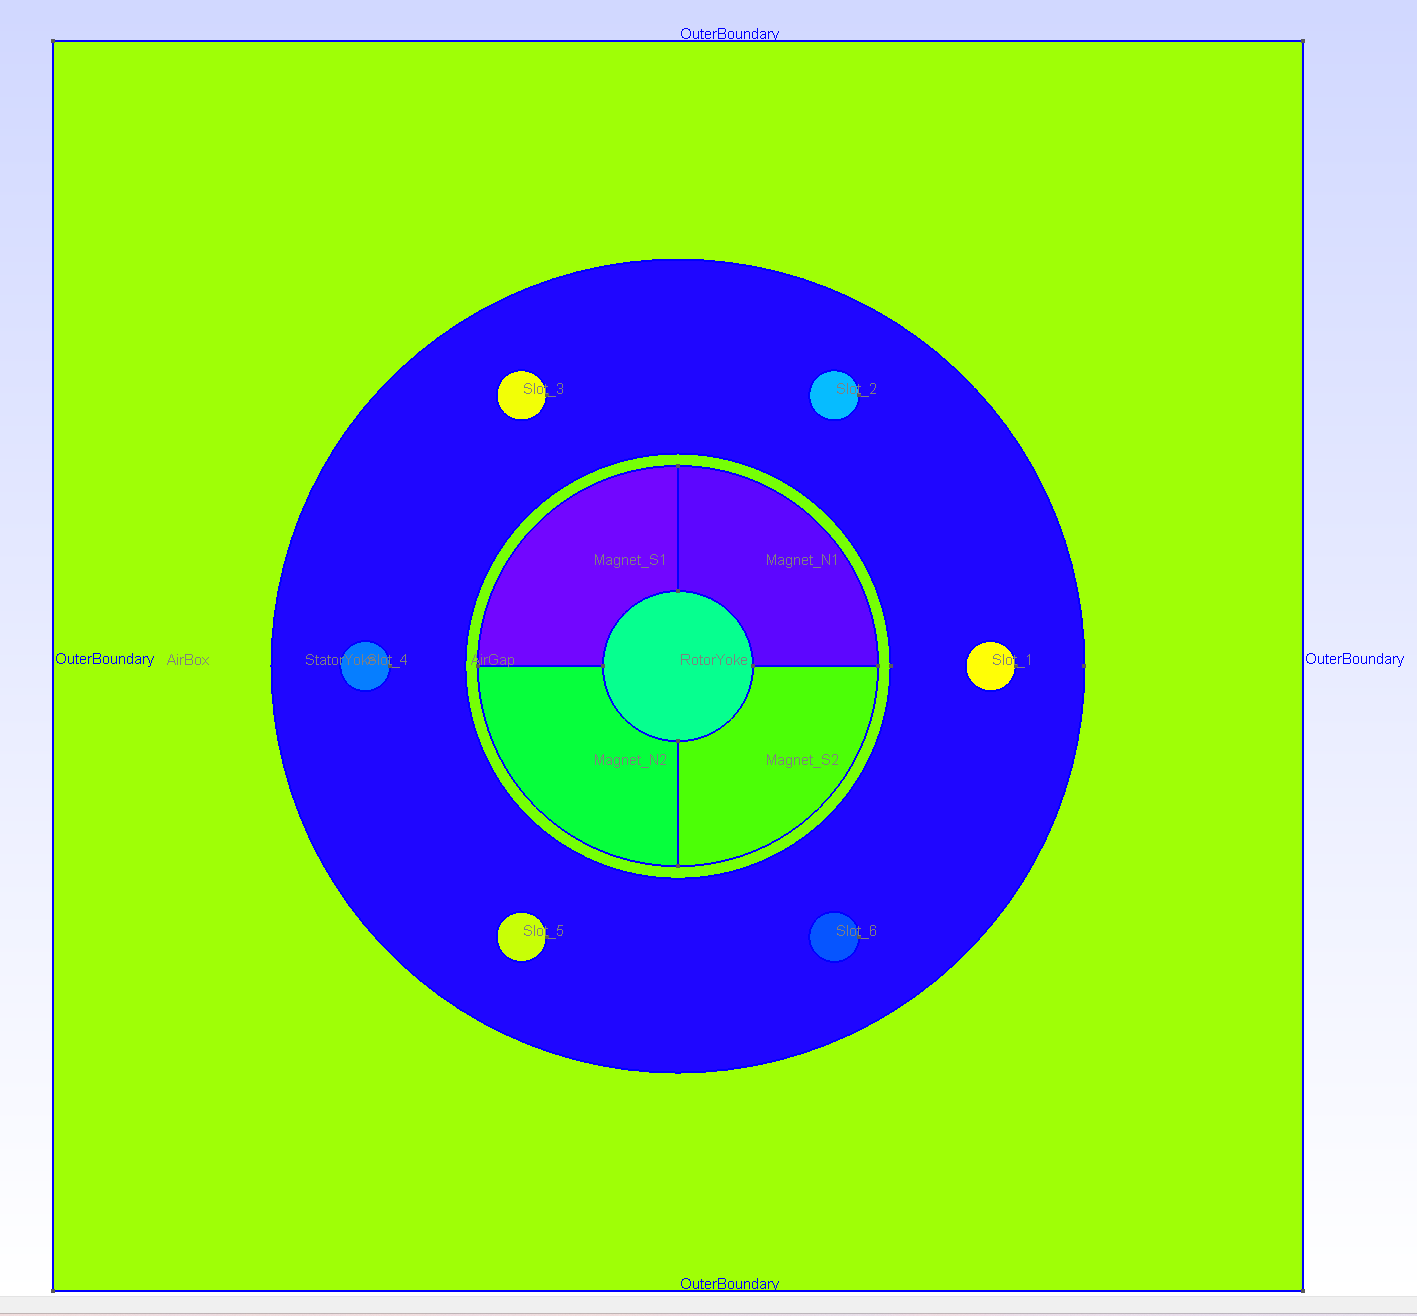

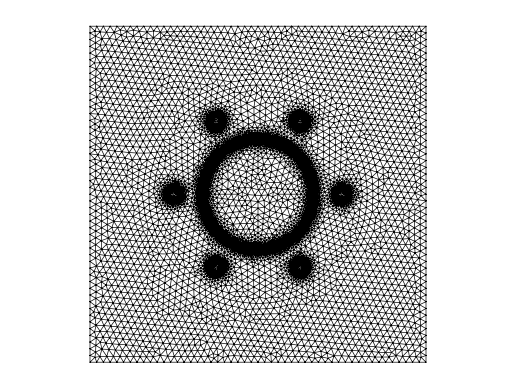

In [51]:
import meshio
from skfem import *
from skfem.helpers import dot, grad
import numpy as np

from skfem.io.meshio import from_meshio

# Add repository root to Python path. Helps to find files and modules
from pathlib import Path
import sys
sys.path.insert(0, str(Path.cwd().parent))


m = meshio.read("mesh/mesh_ex6.msh")

mesh = from_meshio(m)

from skfem.visuals.matplotlib import draw
import matplotlib.pyplot as plt

import matplotlib.tri as mtri

draw(mesh)
plt.axis("equal")
plt.show()

Define basis for each region

In [69]:
from skfem import Basis, ElementTriP1

e = ElementTriP1()
basis = Basis(mesh, e)

basis_rotor_yoke = basis.with_elements(mesh.subdomains["RotorYoke"])
basis_stator_yoke = basis.with_elements(mesh.subdomains["StatorYoke"])
basis_air_box = basis.with_elements(mesh.subdomains["AirBox"])
basis_air_gap = basis.with_elements(mesh.subdomains["AirGap"])

basis_magnet_N1 = basis.with_elements(mesh.subdomains["Magnet_N1"])
basis_magnet_S1 = basis.with_elements(mesh.subdomains["Magnet_S1"])
basis_magnet_N2 = basis.with_elements(mesh.subdomains["Magnet_N2"])
basis_magnet_S2 = basis.with_elements(mesh.subdomains["Magnet_S2"])

In [107]:

# Slot to phzse current mapping
"""
Slot_1 → A+
Slot_2 → B−
Slot_3 → C+
Slot_4 → A−
Slot_5 → B+
Slot_6 → C−
"""

slot_bases = [
    basis.with_elements(mesh.subdomains[f"Slot_{i}"])
    for i in range(1, 7)
]

# For example Slot_1 → A+
print(slot_bases[0])

# Evaluate slot area for to solve the current denisty
# Test winding area
from skfem import Functional
@Functional
def area(w):
    return 1.0

print()
slot_area = area.assemble(slot_bases[0]) 
print("In units of mm: ", slot_area)

<skfem CellBasis(MeshTri1, ElementTriP1) object>
  Number of elements: 254
  Number of DOFs: 9824
  Size: 54864 B

In units of mm:  50.07820143519463


In [ ]:
mu0 = 4 * np.pi * 1e-7
mu_air = mu0
mu_pm = mu0
mu_iron = 1000 * mu0
# w.mu little confusing but it just wraps the permeability to some variable w
@BilinearForm
def laplace(A, v, w):
    return 1/w.mu*dot(grad(A), grad(v))

I_0 = 0
f = 50
omega = 2*np.pi*f
t = 0  # lets keep now only one time moment, later we can loop this

I_A = I_0*np.cos(omega*t)
I_B = I_0*np.cos(omega*t - 2*np.pi/3)
I_C = I_0*np.cos(omega*t - 4*np.pi/3)

J_A = I_A / slot_area
J_B = I_B / slot_area
J_C = I_C / slot_area
@LinearForm
def slot_rhs(v, w):
    return w.J * v

Br = 1.2 # Remanence 
@LinearForm
def magnet_rhs(v, w):
    Brx = w.Brx
    Bry = w.Bry
    mu = w.mu  

    return 1/mu * (
        Brx * v.grad[1]
        -
        Bry * v.grad[0]
    )

# Assemble left hand side. We have linear materials, so just change permeability

# RotorYoke and StatorYoke are modelled as magnetic iron
S_mat = laplace.assemble(basis_rotor_yoke, mu=mu_iron)
S_mat += laplace.assemble(basis_stator_yoke, mu=mu_iron)

# Other parts are modelled as non magnetic
S_mat += laplace.assemble(basis_air_box, mu=mu_air)
S_mat += laplace.assemble(basis_air_gap, mu=mu_air)
# Magnets have remanence, but are not getting magnetized by other fields
S_mat += laplace.assemble(basis_magnet_N1, mu=mu_air)
S_mat += laplace.assemble(basis_magnet_S1, mu=mu_air)
S_mat += laplace.assemble(basis_magnet_N2, mu=mu_air)
S_mat += laplace.assemble(basis_magnet_S2, mu=mu_air)

# Slots (air-filled)
for basis_i in slot_bases:
    S_mat += laplace.assemble(basis_i, mu=mu_air)

# Assemble right hand side for slots. Add current density source to each slot. We use 3phase currents
b =  slot_rhs.assemble(slot_bases[0], J = +J_A)
b +=  slot_rhs.assemble(slot_bases[1], J = -J_B)
b +=  slot_rhs.assemble(slot_bases[2], J = +J_C)
b +=  slot_rhs.assemble(slot_bases[3], J = -J_A)
b +=  slot_rhs.assemble(slot_bases[4], J = +J_B)
b +=  slot_rhs.assemble(slot_bases[5], J = -J_C)


# Assemble right hand side for magnets. These are the remanence source, they behave as current sources in wea form.

# We want to magnetize magnet radially, so we need their x,y coordinates. Then we can compute the radial direction

# MAGNET NORTH 1
x = basis_magnet_N1.global_coordinates().value[0]
y = basis_magnet_N1.global_coordinates().value[1]

r = np.sqrt(x**2 + y**2)

Brx = Br * x / r
Bry = Br * y / r

# Keep the direction of magnetization positive for north poles
b += magnet_rhs.assemble(
    basis_magnet_N1,
    Brx=Brx,
    Bry=Bry,
    mu=mu_pm,
)

# MAGNET SOUTH  1
x = basis_magnet_S1.global_coordinates().value[0]
y = basis_magnet_S1.global_coordinates().value[1]

r = np.sqrt(x**2 + y**2)

Brx = Br * x / r
Bry = Br * y / r

# Reverse the direction of magnetization for south poles
b += magnet_rhs.assemble(
    basis_magnet_S1,
    Brx=-Brx,
    Bry=-Bry,
    mu=mu_pm,
)

# MAGNET NORTH  2
x = basis_magnet_N2.global_coordinates().value[0]
y = basis_magnet_N2.global_coordinates().value[1]

r = np.sqrt(x**2 + y**2)

Brx = Br * x / r
Bry = Br * y / r

b += magnet_rhs.assemble(
    basis_magnet_N2,
    Brx=Brx,
    Bry=Bry,
    mu=mu_pm,
)


# MAGNET SOUTH 2
x = basis_magnet_S2.global_coordinates().value[0]
y = basis_magnet_S2.global_coordinates().value[1]

r = np.sqrt(x**2 + y**2)

Brx = Br * x / r
Bry = Br * y / r

# Reverse the direction of magnetization for south poles
b += magnet_rhs.assemble(
    basis_magnet_S2,
    Brx=-Brx,
    Bry=-Bry,
    mu=mu_pm,
)


Next we add A_z=0 on the airbox boundaries and solve the linear system

In [101]:
S_mat, b = enforce(S_mat, b, D=mesh.boundary_nodes())

A_z = solve(S_mat, b)

Visualize solved vector potential

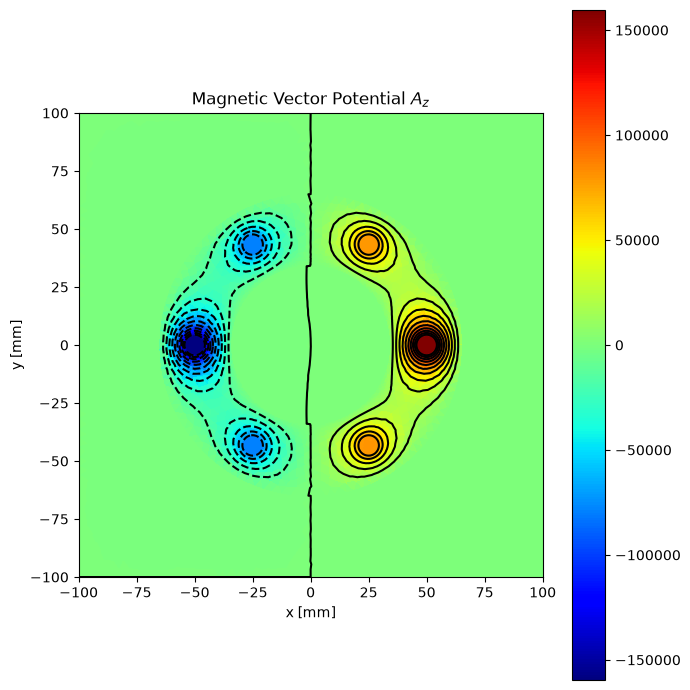

In [102]:
import matplotlib.pyplot as plt
from skfem.visuals.matplotlib import plot

fig, ax = plt.subplots(figsize=(7,7))


plot(
    mesh,
    A_z,
    shading="gouraud",
    colorbar=True,
    ax=ax,
)

plot(
    mesh,
    A_z,
    ax=ax,
    levels=30,
    color="black",
    linewidths=0.4,
)

ax.set_aspect("equal")
ax.set_title(r"Magnetic Vector Potential $A_z$")
ax.set_xlabel("x [mm]")
ax.set_ylabel("y [mm]")

plt.tight_layout()
#from skfem.visuals.matplotlib import draw

#draw(mesh, ax=ax)


Now we compute Bx and By with partial derivatives to plot B field

In [103]:

# basis.interpolate(A_z) creates a finite element function Ah = sum(Ni*Ai)   ,  where Ni is shape function and Ai is nodal vectorpotential values
uh = basis.interpolate(A_z)

# grad object has the dA/dx and dA/dy components
dAz_dx = uh.grad[0]
dAz_dy = uh.grad[1]

Bx = dAz_dy
By = -dAz_dx

# each quanrature point  has own gradient (P1 elem should have constant gradient) This way we collpase this into one gradient value per element
Bx_elem = Bx.mean(axis=1)
By_elem = By.mean(axis=1)

Bnorm_elem = np.sqrt(Bx_elem**2 + By_elem**2)

mesh.p: (2, 9824)
mesh.t: (3, 19446)
centers: (2, 19446)
Bx_plot: (19446,)


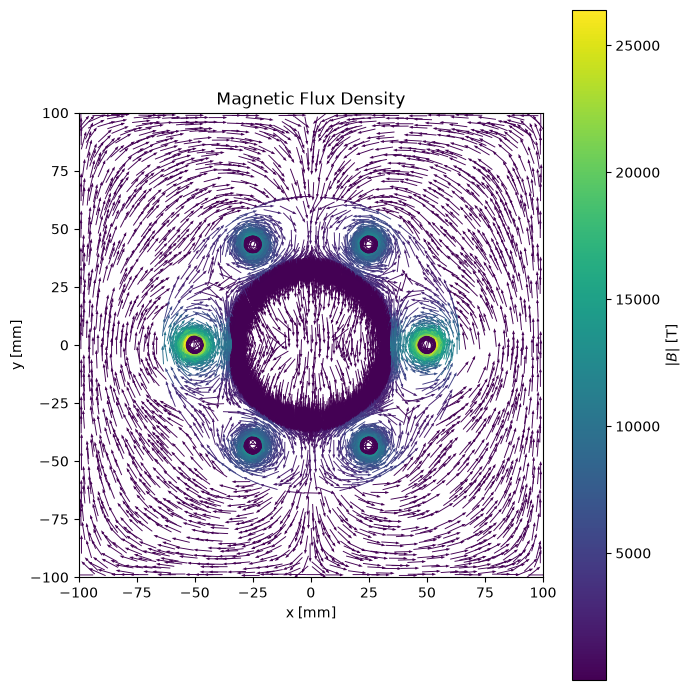

In [104]:
import numpy as np
import matplotlib.pyplot as plt

# Element connectivity
# Coordinates of the three vertices of every element
x = mesh.p[0, mesh.t]   # shape: (3, nelements)
y = mesh.p[1, mesh.t]   # shape: (3, nelements)

# Element centroids
centers = np.vstack([
    x.mean(axis=0),
    y.mean(axis=0)
])


eps = 1e-14

Bx_plot = Bx_elem / (Bnorm_elem + eps)
By_plot = By_elem / (Bnorm_elem + eps)

fig, ax = plt.subplots(figsize=(7,7))

step = 2
print("mesh.p:", mesh.p.shape)
print("mesh.t:", mesh.t.shape)
print("centers:", centers.shape)
print("Bx_plot:", Bx_plot.shape)
q = ax.quiver(
    centers[0][::step],
    centers[1][::step],
    Bx_plot[::step],
    By_plot[::step],
    Bnorm_elem[::step],
    cmap="viridis",
    pivot="mid",
    scale=25,
    width=0.002,
    headwidth=3,
    headlength=4
)

fig.colorbar(q, ax=ax, label=r"$|B|$ [T]")

# Zoom into the region around the C-core
xmin, ymin = mesh.p.min(axis=1)
xmax, ymax = mesh.p.max(axis=1)
d = max(xmax - xmin, ymax - ymin)

margin = 0.0 * d  # CHANGE TO ZOOM

ax.set_xlim(xmin + margin, xmax - margin)
ax.set_ylim(ymin + margin, ymax - margin)
ax.set_xlabel("x [mm]")
ax.set_ylabel("y [mm]")
ax.set_aspect("equal")

ax.set_title("Magnetic Flux Density")

plt.tight_layout()

### Plotting B for each node
Compute B for each node instead of element.
The gradient is constant in P1 elementents, and is not continious over elements. We have to do some averaging, if node that shares multiple elements have different gradient values.

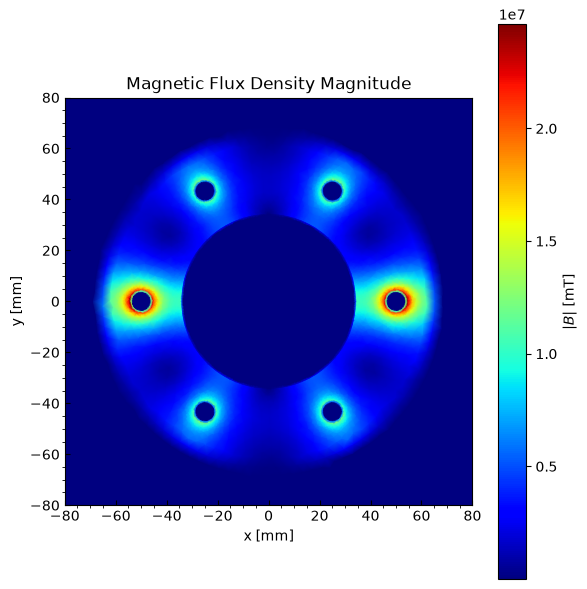

In [105]:
import matplotlib.pyplot as plt
import matplotlib.tri as mtri


triang = mtri.Triangulation(
    mesh.p[0],
    mesh.p[1],
    mesh.t.T
)

# convert element values to nodal values
Bnorm_node = np.zeros(mesh.p.shape[1])
count = np.zeros(mesh.p.shape[1])

for elem, tri in enumerate(mesh.t.T):
    for node in tri:
        Bnorm_node[node] += Bnorm_elem[elem]
        count[node] += 1

# B is constant over each element. Nodal values require averaging
Bnorm_node /= count

fig, ax = plt.subplots(figsize=(6, 6))

plot(
    mesh,
    1000 * Bnorm_node,
    ax=ax,
    shading='gouraud',
    colorbar=True
)

# Zoom into the region around the C-core
xmin, ymin = mesh.p.min(axis=1)
xmax, ymax = mesh.p.max(axis=1)
d = max(xmax - xmin, ymax - ymin)
margin = 0.1 * d  # CHANGE TO ZOOM
ax.set_xlim(xmin + margin, xmax - margin)
ax.set_ylim(ymin + margin, ymax - margin)

ax.set_title("Magnetic Flux Density Magnitude")
ax.set_xlabel("x [mm]")
ax.set_ylabel("y [mm]")
ax.set_aspect("equal")

ax.tick_params(direction='in')
ax.minorticks_on()

# Label the colorbar
cbar = fig.axes[-1]
cbar.set_ylabel(r"$|B|$ [mT]")

fig.tight_layout()
#draw(mesh, ax=ax)

plt.show()